In [24]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Load your dataset
# Replace 'your_dataset.csv' with your actual dataset file
data = pd.read_csv('diabetes.csv')

# Separate features (X) and target variable (y)
X = data.drop(columns=['Outcome'])  # Replace 'target' with the name of your target column
y = data['Outcome']



In [ ]:
# Split data into training+validation (85%) and testing (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# Further split training+validation into training (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, stratify=y_train_val, random_state=42)

# Balance the training set using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)



In [ ]:
# Define a pipeline for scaling and model training
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scale the data
    ('classifier', RandomForestClassifier(random_state=42))  # Use RandomForest as a base model
])

# Define hyperparameter grid for tuning
param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # Number of trees
    'classifier__max_depth': [None, 10, 20, 30],  # Tree depth
    'classifier__min_samples_split': [2, 5, 10],  # Min samples to split
    'classifier__min_samples_leaf': [1, 2, 4]  # Min samples per leaf
}



In [ ]:
# Use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_balanced, y_train_balanced)

# Get the best model from grid search
best_model = grid_search.best_estimator_

In [ ]:
# Evaluate on validation data
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

In [ ]:
# Evaluate on test data
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [ ]:
# Print results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Test Accuracy: {test_accuracy}")
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Validation Accuracy: 0.7413793103448276
Test Accuracy: 0.7844827586206896
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        76
           1       0.66      0.78      0.71        40

    accuracy                           0.78       116
   macro avg       0.76      0.78      0.77       116
weighted avg       0.80      0.78      0.79       116




Test Accuracy of the random forest model: 78.45%

Confusion Matrix:
[[60 16]
 [ 9 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        76
           1       0.66      0.78      0.71        40

    accuracy                           0.78       116
   macro avg       0.76      0.78      0.77       116
weighted avg       0.80      0.78      0.79       116



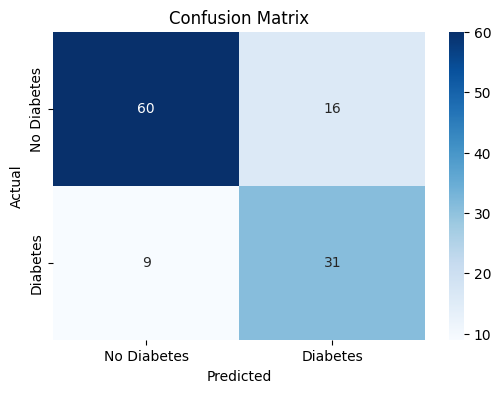

In [27]:
# Model Evaluation
test_accuracy = accuracy_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)
class_report = classification_report(y_test, y_test_pred)

print(f"\nTest Accuracy of the random forest model: {test_accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualizing the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


<ipython-input-31-3d4d13ba46e9>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


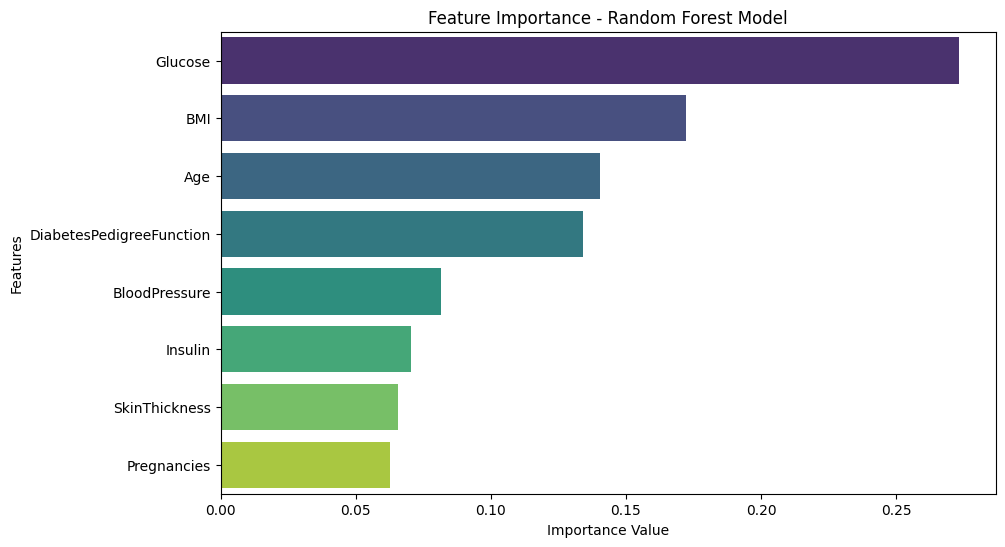

In [31]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best model
# Note: RandomForestClassifier has the attribute `feature_importances_`
feature_importances = best_model.named_steps['classifier'].feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.show()

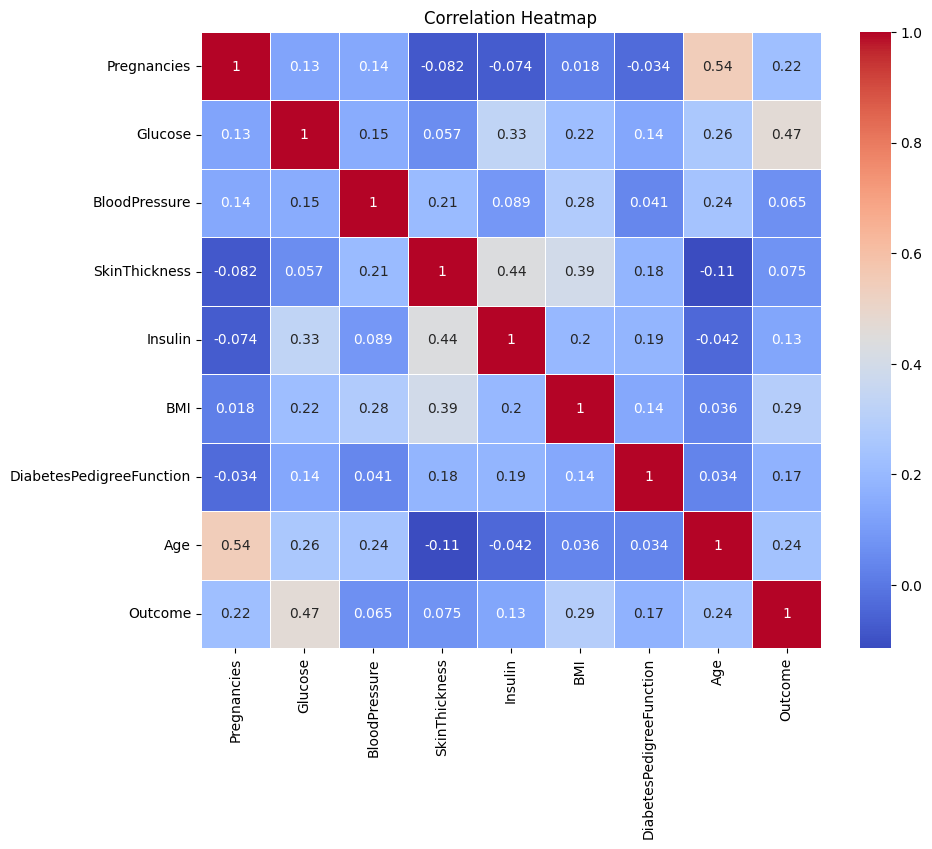

In [32]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()